Imports

In [60]:
import pandas as pd
import numpy as np
import time
import math
import datetime
import seaborn as sns
import matplotlib.pylab as plt


import dask.dataframe as dd # To work with large data sets

In [61]:
# Some globals
PROJECT_PATH  = './result/' #'/content/drive/MyDrive/CENG574_PROJECT'
RAW_DATA_PATH = PROJECT_PATH + 'final_combined.csv' #'/yellow_tripdata_2015-01.csv'
FEATURE_SELECTION_OUTPUT_NAME = 'pruned_yellow_tripdata_2015-01.parquet' # Our selected features (before normalization)

FEATURE_SELECTION_DATA_PATH = PROJECT_PATH + FEATURE_SELECTION_OUTPUT_NAME

In [62]:
#from google.colab import drive
#drive.mount('/content/drive')

# Dataset Preparation

In [63]:
# NOTE: Added shortcut to mydrive
df = pd.read_csv(RAW_DATA_PATH)



In [64]:
# Feature names and types

print(f"Number of samples: {len(df)}")
print("="*50)

info_df = pd.DataFrame({
    "Feature Name": df.columns,
    "Type": df.dtypes.values
})

print(info_df)
print("="*50)

df.head()

Number of samples: 12748829
             Feature Name     Type
0    tpep_pickup_datetime   object
1   tpep_dropoff_datetime   object
2         passenger_count    int64
3           trip_distance  float64
4        pickup_longitude  float64
5         pickup_latitude  float64
6       dropoff_longitude  float64
7        dropoff_latitude  float64
8            total_amount  float64
9            PULocationID  float64
10           DOLocationID  float64


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,total_amount,PULocationID,DOLocationID
0,2015-01-15 19:05:43,2015-01-15 19:15:09,5,1.57,-73.978424,40.746208,-73.980217,40.728542,11.6,170.0,79.0
1,2015-01-25 00:13:06,2015-01-25 00:18:30,1,1.18,-73.983025,40.767818,-73.968307,40.763149,9.1,142.0,237.0
2,2015-01-04 13:44:54,2015-01-04 13:50:29,1,1.10,-73.967979,40.802135,-73.977684,40.787266,9.3,24.0,239.0
3,2015-01-04 13:44:54,2015-01-04 13:47:15,1,0.50,-73.962517,40.770039,-73.967735,40.762856,5.8,237.0,237.0
4,2015-01-15 14:00:45,2015-01-15 14:47:12,1,10.89,-74.006409,40.739765,-73.871193,40.774212,55.8,158.0,138.0


## Outlier Elimination and Feature Selection

**Disclaimer**

Based on
https://www.kaggle.com/code/elemento/nyc-yellowtriptaxi/notebook

* It is inferred from the source https://www.flickr.com/places/info/2459115 that New York is bounded by the location cordinates (lat,long) - (40.5774, -74.15) & (40.9176,-73.7004)

* Hence, any cordinates not within this cordinate range, are not considered by us, as we are only concerned with pickups which originate within New York.



In [65]:
month = dd.from_pandas(df)
print(month.head)

<bound method FrameBase.head of Dask DataFrame Structure:
              tpep_pickup_datetime tpep_dropoff_datetime passenger_count trip_distance pickup_longitude pickup_latitude dropoff_longitude dropoff_latitude total_amount PULocationID DOLocationID
npartitions=1                                                                                                                                                                                    
0                           string                string           int64       float64          float64         float64           float64          float64      float64      float64      float64
12748828                       ...                   ...             ...           ...              ...             ...               ...              ...          ...          ...          ...
Dask Name: frompandas, 1 expression
Expr=df>


In [66]:

outlier_locations_pickup = month[((month.pickup_longitude <= -74.15) | (month.pickup_latitude <= 40.5774)| \
    (month.pickup_longitude >= -73.7004) | (month.pickup_latitude >= 40.9176))]
print("Number of Outlier Pick up Locations:", len(outlier_locations_pickup))


outlier_locations_dropoff = month[((month.dropoff_longitude <= -74.15) | (month.dropoff_latitude <= 40.5774)| \
    (month.dropoff_longitude >= -73.7004) | (month.dropoff_latitude >= 40.9176))]
print("Number of Outlier Drop off Locations:", len(outlier_locations_dropoff))


Number of Outlier Pick up Locations: 247363
Number of Outlier Drop off Locations: 264068


In [67]:
# The timestamps are converted to unix so as to get duration (trip-time) & speed.
# Also, the pickup-times in unix are used while binning

# In the data, we have time in the format "YYYY-MM-DD HH:MM:SS"
# We convert this string to python time format and then into unix time stamp
# https://stackoverflow.com/a/27914405
def convert_to_unix(s):
    return time.mktime(datetime.datetime.strptime(s, "%Y-%m-%d %H:%M:%S").timetuple())

In [68]:
# This block takes about 7 mins to execute

# We return a data-frame which contains the columns
# 1.'passenger_count'   :
# 2.'trip_distance'     :
# 3.'pickup_longitude'  :
# 4.'pickup_latitude'   :
# 5.'dropoff_longitude' :
# 6.'dropoff_latitude'  :
# 7.'total_amount'      : Total fare that was paid
# 8.'trip_times'        : Duration of each trip
# 9.'pickup_times       : Pickup time converted into unix time
# 10.'Speed'            : Velocity of each trip

def return_with_trip_times(month):
    duration = month[['tpep_pickup_datetime','tpep_dropoff_datetime']].compute()

    # Pickups and dropoffs to unix time
    duration_pickup = [convert_to_unix(x) for x in duration['tpep_pickup_datetime'].values]
    duration_drop = [convert_to_unix(x) for x in duration['tpep_dropoff_datetime'].values]

    # Calculate the duration of trips
    # Division by 60 converts the difference from seconds to minutes
    durations = (np.array(duration_drop) - np.array(duration_pickup))/float(60)

    # Append durations of trips and speed in miles/hr to a new dataframe
    new_frame = month[['passenger_count','trip_distance','pickup_longitude','pickup_latitude',
        'dropoff_longitude','dropoff_latitude','total_amount',
        'PULocationID', 'DOLocationID' # NOTE: These are the addition we made (from merge_by_dask notebook)
        ]].compute()

    new_frame['trip_times'] = durations
    new_frame['pickup_times'] = duration_pickup
    new_frame['Speed'] = 60*(new_frame['trip_distance']/new_frame['trip_times'])

    return new_frame

frame_with_durations = return_with_trip_times(month)
frame_with_durations.head()

,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,total_amount,PULocationID,DOLocationID,trip_times,pickup_times,Speed
0,5,1.57,-73.978424,40.746208,-73.980217,40.728542,11.6,170.0,79.0,9.433333,1.421338e+09,9.985866
1,1,1.18,-73.983025,40.767818,-73.968307,40.763149,9.1,142.0,237.0,5.400000,1.422134e+09,13.111111
2,1,1.10,-73.967979,40.802135,-73.977684,40.787266,9.3,24.0,239.0,5.583333,1.420368e+09,11.820896
3,1,0.50,-73.962517,40.770039,-73.967735,40.762856,5.8,237.0,237.0,2.350000,1.420368e+09,12.765957
4,1,10.89,-74.006409,40.739765,-73.871193,40.774212,55.8,158.0,138.0,46.450000,1.421320e+09,14.066738


<Axes: ylabel='trip_times'>

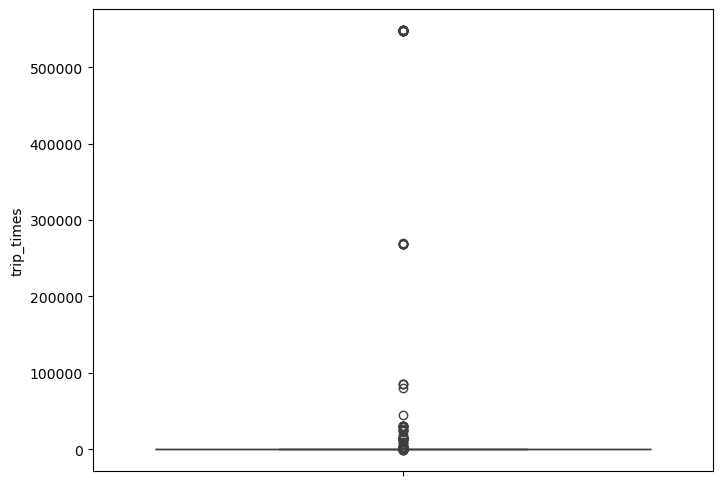

In [69]:
# The skewed box-plot shows us the presence of outliers
plt.figure(figsize = (8, 6))
sns.boxplot(y="trip_times", data = frame_with_durations)

In [70]:
# Calculating 0-100th percentile to find the correct percentile value for removal of outliers
var = frame_with_durations["trip_times"].values
var = np.sort(var, axis = None)

for i in range(0,100,10):
    print("{} percentile value is {}".format(i,var[int(len(var)*(float(i)/100))]))
print ("100 percentile value is", var[-1])



0 percentile value is -1211.0166666666667
10 percentile value is 3.8333333333333335
20 percentile value is 5.383333333333334
30 percentile value is 6.816666666666666
40 percentile value is 8.3
50 percentile value is 9.95
60 percentile value is 11.866666666666667
70 percentile value is 14.283333333333333
80 percentile value is 17.633333333333333
90 percentile value is 23.45
100 percentile value is 548555.6333333333


In [71]:
# Looking further from the 99th percentile
var = frame_with_durations["trip_times"].values
var = np.sort(var,axis = None)

for i in range(90,100):
    print("{} percentile value is {}".format(i,var[int(len(var)*(float(i)/100))]))
print ("100 percentile value is", var[-1])

90 percentile value is 23.45
91 percentile value is 24.35
92 percentile value is 25.383333333333333
93 percentile value is 26.55
94 percentile value is 27.933333333333334
95 percentile value is 29.583333333333332
96 percentile value is 31.683333333333334
97 percentile value is 34.46666666666667
98 percentile value is 38.71666666666667
99 percentile value is 46.75
100 percentile value is 548555.6333333333


In [72]:
# Removing data based on our analysis and TLC regulations
frame_with_durations_modified = frame_with_durations[(frame_with_durations.trip_times > 1) & \
    (frame_with_durations.trip_times < 720)]

In [73]:
frame_with_durations_modified.head()

,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,total_amount,PULocationID,DOLocationID,trip_times,pickup_times,Speed
0,5,1.57,-73.978424,40.746208,-73.980217,40.728542,11.6,170.0,79.0,9.433333,1.421338e+09,9.985866
1,1,1.18,-73.983025,40.767818,-73.968307,40.763149,9.1,142.0,237.0,5.400000,1.422134e+09,13.111111
2,1,1.10,-73.967979,40.802135,-73.977684,40.787266,9.3,24.0,239.0,5.583333,1.420368e+09,11.820896
3,1,0.50,-73.962517,40.770039,-73.967735,40.762856,5.8,237.0,237.0,2.350000,1.420368e+09,12.765957
4,1,10.89,-74.006409,40.739765,-73.871193,40.774212,55.8,158.0,138.0,46.450000,1.421320e+09,14.066738


<Axes: ylabel='trip_times'>

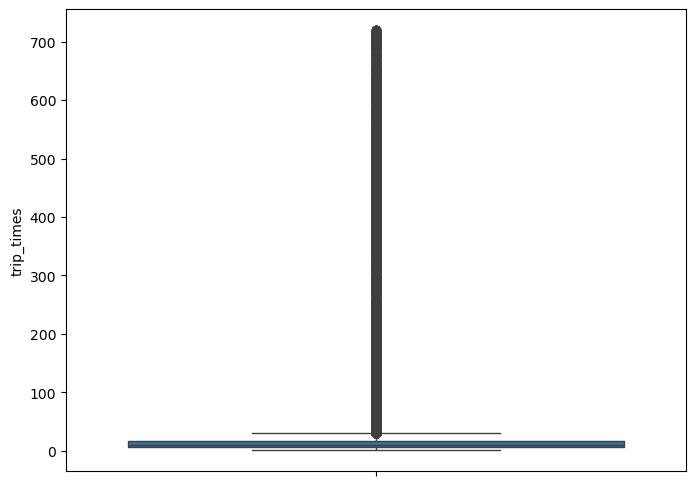

In [74]:
# Box-plot after removal of outliers
plt.figure(figsize = (8, 6))
sns.boxplot(y="trip_times", data = frame_with_durations_modified)

C:\Users\USER\AppData\Local\Temp\ipykernel_32436\1767924054.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tt_sample, hist=True, kde=True)


<Axes: xlabel='trip_times', ylabel='Density'>

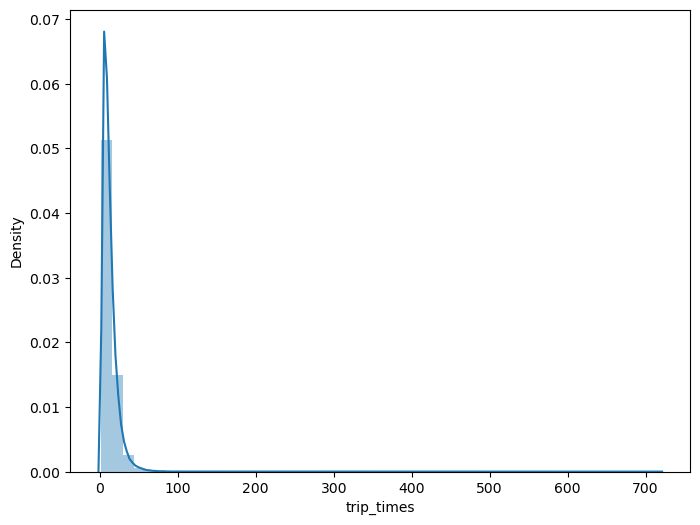

In [75]:
# PDF of trip-times after removing the outliers
tt_sample = frame_with_durations_modified['trip_times'].sample(n = 200000)

plt.figure(figsize = (8, 6))
sns.distplot(tt_sample, hist=True, kde=True)

In [76]:
# Converting the values to log-values to check for log-normal distribution
frame_with_durations_modified['log_times'] = [math.log(i) for i in frame_with_durations_modified['trip_times'].values]

C:\Users\USER\AppData\Local\Temp\ipykernel_32436\43788407.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  frame_with_durations_modified['log_times'] = [math.log(i) for i in frame_with_durations_modified['trip_times'].values]


C:\Users\USER\AppData\Local\Temp\ipykernel_32436\1634925531.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(ltt_sample, hist=True, kde=True)


<Axes: xlabel='log_times', ylabel='Density'>

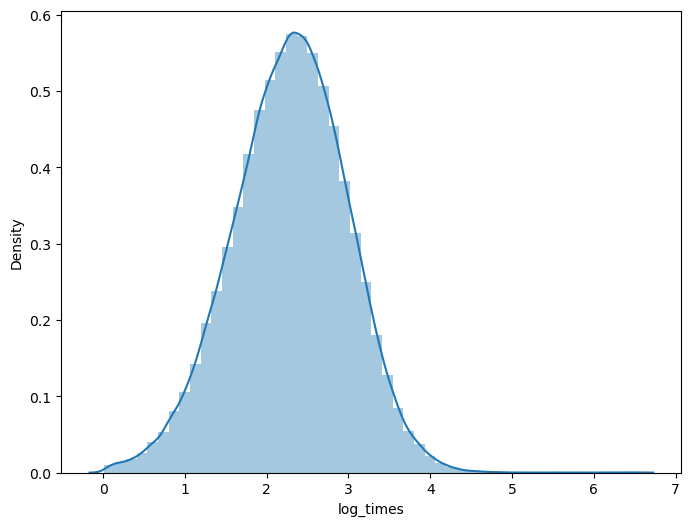

In [77]:
# PDF of log-values of trip-times
ltt_sample = frame_with_durations_modified['log_times'].sample(n = 200000)

plt.figure(figsize = (8, 6))
sns.distplot(ltt_sample, hist=True, kde=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_32436\2727722116.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  frame_with_durations_modified['Speed'] = 60 * (frame_with_durations_modified['trip_distance'] / \


<Axes: ylabel='Speed'>

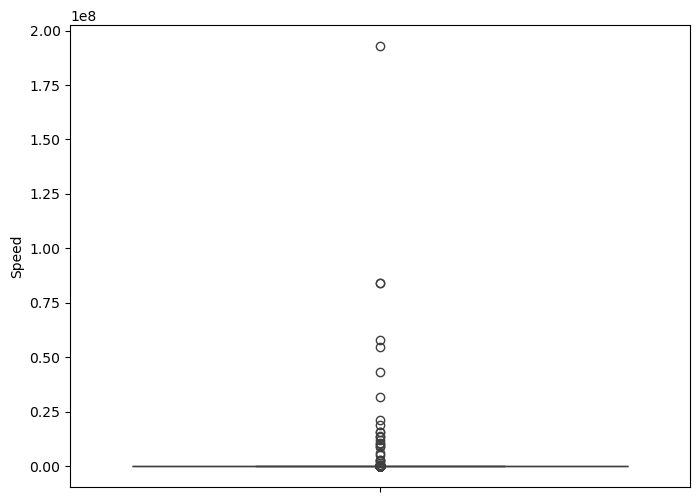

In [78]:
# Check for any outliers in the data after trip duration outliers have been removed
# Box-plot for speeds with outliers
frame_with_durations_modified['Speed'] = 60 * (frame_with_durations_modified['trip_distance'] / \
    frame_with_durations_modified['trip_times'])

plt.figure(figsize = (8, 6))
sns.boxplot(y="Speed", data = frame_with_durations_modified)

In [79]:
# Calculating speed values at each percentile: 0,10,20,30,40,50,60,70,80,90,100
var = frame_with_durations_modified["Speed"].values
var = np.sort(var,axis = None)
for i in range(0,100,10):
    print("{} percentile value is {}".format(i,var[int(len(var)*(float(i)/100))]))
print("100 percentile value is ",var[-1])

0 percentile value is 0.0
10 percentile value is 6.409495548961425
20 percentile value is 7.8096571028691395
30 percentile value is 8.929133858267717
40 percentile value is 9.98019801980198
50 percentile value is 11.06865671641791
60 percentile value is 12.286689419795222
70 percentile value is 13.796407185628745
80 percentile value is 15.963157894736842
90 percentile value is 20.186915887850468
100 percentile value is  192857142.85714284


In [80]:
# Calculating speed values at each percentile: 90,91,92,93,94,95,96,97,98,99,100
var = frame_with_durations_modified["Speed"].values
var = np.sort(var,axis = None)
for i in range(90,100):
    print("{} percentile value is {}".format(i,var[int(len(var)*(float(i)/100))]))
print("100 percentile value is ",var[-1])

90 percentile value is 20.186915887850468
91 percentile value is 20.91634309918814
92 percentile value is 21.752895752895753
93 percentile value is 22.721893491124263
94 percentile value is 23.844155844155843
95 percentile value is 25.18251214434421
96 percentile value is 26.80851063829787
97 percentile value is 28.842975206611573
98 percentile value is 31.59111691704768
99 percentile value is 35.75134305448964
100 percentile value is  192857142.85714284


In [81]:
# Calculating speed values at each percentile: 99.0,99.1,99.2,99.3,99.4,99.5,99.6,99.7,99.8,99.9,100
var = frame_with_durations_modified["Speed"].values
var = np.sort(var,axis = None)
for i in np.arange(0.0, 1.0, 0.1):
    print("{} percentile value is {}".format(99+i,var[int(len(var)*(float(99+i)/100))]))
print("100 percentile value is ",var[-1])

99.0 percentile value is 35.75134305448964
99.1 percentile value is 36.310679611650485
99.2 percentile value is 36.91470054446461
99.3 percentile value is 37.588235294117645
99.4 percentile value is 38.330308529945555
99.5 percentile value is 39.17580340264651
99.6 percentile value is 40.15384615384615
99.7 percentile value is 41.33793103448275
99.8 percentile value is 42.86631016042781
99.9 percentile value is 45.3107822410148
100 percentile value is  192857142.85714284


In [82]:
# Removing further outliers based on the 99.9th percentile value
frame_with_durations_modified = frame_with_durations[(frame_with_durations.Speed > 0) & \
    (frame_with_durations.Speed < 45.31)]

In [83]:

avg_speed = sum(frame_with_durations_modified["Speed"]) / float(len(frame_with_durations_modified["Speed"]))
print(f"Average speed of cabs in New-York: {avg_speed}")


Average speed of cabs in New-York: 12.450137684911603


### Trip Durations

<Axes: ylabel='trip_distance'>

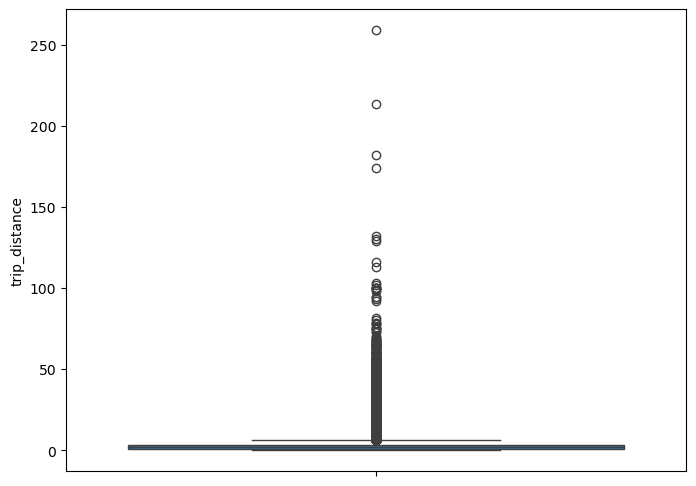

In [84]:
# Up to now, we have removed the outliers based on trip durations and cab speeds
# Let's try if there are any outliers in trip distances
# Box-plot showing outliers in trip-distance values

plt.figure(figsize = (8, 6))
sns.boxplot(y = "trip_distance", data = frame_with_durations_modified)

In [85]:
# Calculating trip distance values at each percentile: 0,10,20,30,40,50,60,70,80,90,100
var = frame_with_durations_modified["trip_distance"].values
var = np.sort(var,axis = None)
for i in range(0,100,10):
    print("{} percentile value is {}".format(i,var[int(len(var)*(float(i)/100))]))
print("100 percentile value is ",var[-1])

0 percentile value is 0.01
10 percentile value is 0.66
20 percentile value is 0.9
30 percentile value is 1.1
40 percentile value is 1.39
50 percentile value is 1.69
60 percentile value is 2.07
70 percentile value is 2.6
80 percentile value is 3.6
90 percentile value is 5.97
100 percentile value is  258.9


In [86]:
# Calculating trip distance values at each percentile: 90,91,92,93,94,95,96,97,98,99,100
var = frame_with_durations_modified["trip_distance"].values
var = np.sort(var,axis = None)
for i in range(90,100):
    print("{} percentile value is {}".format(i,var[int(len(var)*(float(i)/100))]))
print("100 percentile value is ",var[-1])

90 percentile value is 5.97
91 percentile value is 6.45
92 percentile value is 7.07
93 percentile value is 7.85
94 percentile value is 8.72
95 percentile value is 9.6
96 percentile value is 10.6
97 percentile value is 12.1
98 percentile value is 16.03
99 percentile value is 18.17
100 percentile value is  258.9


In [87]:
# Calculating trip distance values at each percentile: 99.0,99.1,99.2,99.3,99.4,99.5,99.6,99.7,99.8,99.9,100
var = frame_with_durations_modified["trip_distance"].values
var = np.sort(var,axis = None)
for i in np.arange(0.0, 1.0, 0.1):
    print("{} percentile value is {}".format(99+i,var[int(len(var)*(float(99+i)/100))]))
print("100 percentile value is ",var[-1])

99.0 percentile value is 18.17
99.1 percentile value is 18.37
99.2 percentile value is 18.6
99.3 percentile value is 18.83
99.4 percentile value is 19.13
99.5 percentile value is 19.5
99.6 percentile value is 19.96
99.7 percentile value is 20.5
99.8 percentile value is 21.22
99.9 percentile value is 22.57
100 percentile value is  258.9


In [88]:
# Removing further outliers based on the 99.9th percentile value
frame_with_durations_modified=frame_with_durations[(frame_with_durations.trip_distance > 0) & \
    (frame_with_durations.trip_distance < 23)]

<Axes: ylabel='trip_distance'>

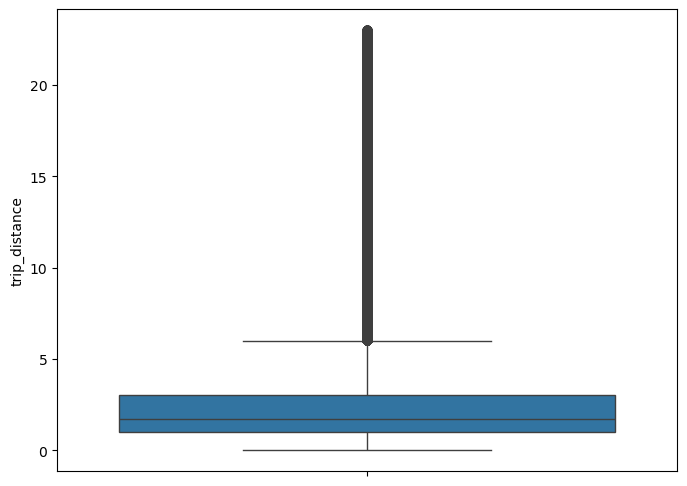

In [89]:
# Box-plot after removal of outliers
plt.figure(figsize = (8, 6))
sns.boxplot(y="trip_distance", data = frame_with_durations_modified)

### Total Fare

<Axes: ylabel='total_amount'>

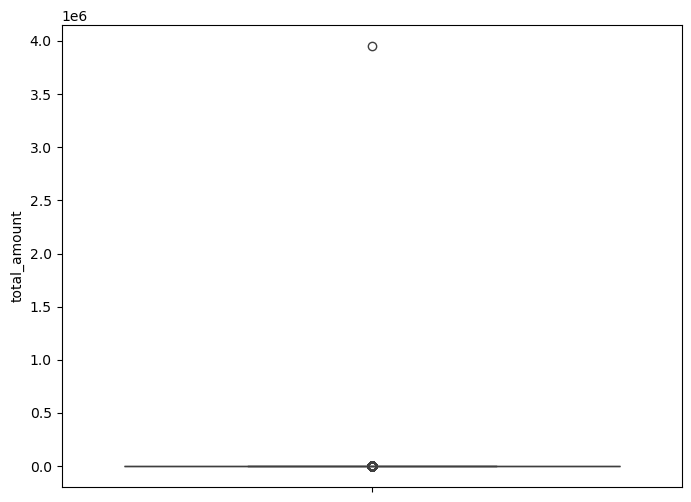

In [90]:
# Up to now we have removed the outliers based on trip durations, cab speeds, and trip distances
# Let's try if there are any outliers in the total_amount
# Box-plot showing outliers in fare
plt.figure(figsize = (8, 6))
sns.boxplot(y="total_amount", data = frame_with_durations_modified)

In [91]:
# Calculating total fare amount values at each percentile: 0,10,20,30,40,50,60,70,80,90,100
var = frame_with_durations_modified["total_amount"].values
var = np.sort(var,axis = None)
for i in range(0,100,10):
    print("{} percentile value is {}".format(i,var[int(len(var)*(float(i)/100))]))
print("100 percentile value is ",var[-1])

0 percentile value is -242.55
10 percentile value is 6.3
20 percentile value is 7.8
30 percentile value is 8.8
40 percentile value is 9.8
50 percentile value is 11.16
60 percentile value is 12.8
70 percentile value is 14.8
80 percentile value is 18.3
90 percentile value is 25.8
100 percentile value is  3950611.6


In [92]:
# Calculating total fare amount values at each percentile: 90,91,92,93,94,95,96,97,98,99,100
var = frame_with_durations_modified["total_amount"].values
var = np.sort(var,axis = None)
for i in range(90,100):
    print("{} percentile value is {}".format(i,var[int(len(var)*(float(i)/100))]))
print("100 percentile value is ",var[-1])

90 percentile value is 25.8
91 percentile value is 27.3
92 percentile value is 29.3
93 percentile value is 31.8
94 percentile value is 34.8
95 percentile value is 38.53
96 percentile value is 42.6
97 percentile value is 48.13
98 percentile value is 58.13
99 percentile value is 66.13
100 percentile value is  3950611.6


In [93]:
# Calculating total fare amount values at each percentile: 99.0,99.1,99.2,99.3,99.4,99.5,99.6,99.7,99.8,99.9,100
var = frame_with_durations_modified["total_amount"].values
var = np.sort(var,axis = None)
for i in np.arange(0.0, 1.0, 0.1):
    print("{} percentile value is {}".format(99+i,var[int(len(var)*(float(99+i)/100))]))
print("100 percentile value is ",var[-1])

99.0 percentile value is 66.13
99.1 percentile value is 68.13
99.2 percentile value is 69.6
99.3 percentile value is 69.6
99.4 percentile value is 69.73
99.5 percentile value is 69.75
99.6 percentile value is 69.76
99.7 percentile value is 72.58
99.8 percentile value is 75.35
99.9 percentile value is 88.28
100 percentile value is  3950611.6


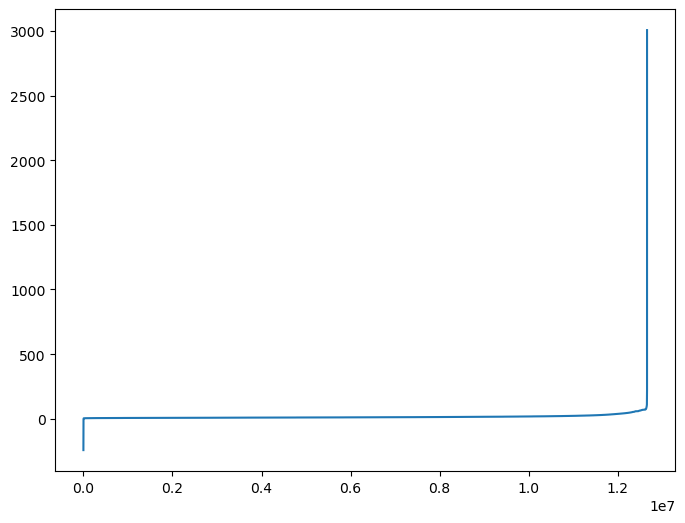

In [94]:
# The below plot shows us the fare values (sorted) to find a sharp increase, to remove those values
# as outliers. Plot the fare amount excluding the last two values in sorted data
plt.figure(figsize = (8, 6))
plt.plot(var[:-2])
plt.show()

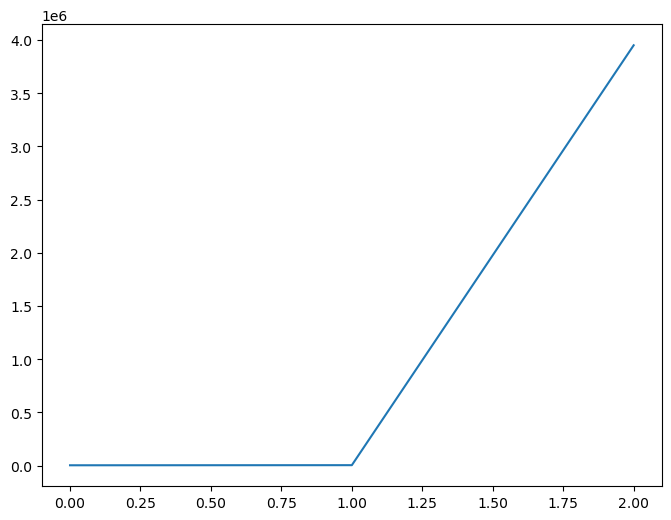

In [95]:
# A very sharp increase in fare values can be seen. Plotting last three total fare values
# And we can observe that there is a shared increase in the values
plt.figure(figsize = (8, 6))
plt.plot(var[-3:])
plt.show()

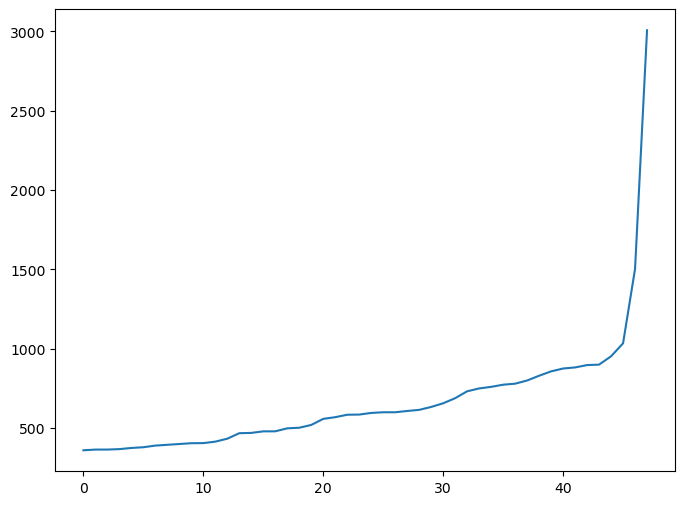

In [96]:
# Now looking at values not including the last two points, we again find a drastic increase at
# around 1000 fare values. We plot the last 50 values, excluding the last two values
plt.figure(figsize = (8, 6))
plt.plot(var[-50:-2])
plt.show()

### Removing Outliers

In [97]:
# Removing all outliers based on our univariate analysis above
def remove_outliers(new_frame):
    a = new_frame.shape[0]
    print("Number of pickup records:", a)

    temp_frame = new_frame[((new_frame.dropoff_longitude >= -74.15) & (new_frame.dropoff_longitude <= -73.7004) &\
        (new_frame.dropoff_latitude >= 40.5774) & (new_frame.dropoff_latitude <= 40.9176)) & \
        ((new_frame.pickup_longitude >= -74.15) & (new_frame.pickup_latitude >= 40.5774)& \
        (new_frame.pickup_longitude <= -73.7004) & (new_frame.pickup_latitude <= 40.9176))]
    b = temp_frame.shape[0]
    print("Number of outlier coordinates lying outside NY boundaries:", (a-b))

    temp_frame = new_frame[(new_frame.trip_times > 0) & (new_frame.trip_times < 720)]
    c = temp_frame.shape[0]
    print("Number of outliers from trip times analysis:", (a-c))

    temp_frame = new_frame[(new_frame.trip_distance > 0) & (new_frame.trip_distance < 23)]
    d = temp_frame.shape[0]
    print ("Number of outliers from trip distance analysis:", (a-d))

    temp_frame = new_frame[(new_frame.Speed <= 45.31) & (new_frame.Speed >= 0)]
    e = temp_frame.shape[0]
    print ("Number of outliers from speed analysis:", (a-e))

    temp_frame = new_frame[(new_frame.total_amount < 1000) & (new_frame.total_amount > 0)]
    f = temp_frame.shape[0]
    print ("Number of outliers from fare analysis:", (a-f))


    new_frame = new_frame[((new_frame.dropoff_longitude >= -74.15) & (new_frame.dropoff_longitude <= -73.7004) &\
        (new_frame.dropoff_latitude >= 40.5774) & (new_frame.dropoff_latitude <= 40.9176)) & \
        ((new_frame.pickup_longitude >= -74.15) & (new_frame.pickup_latitude >= 40.5774)& \
        (new_frame.pickup_longitude <= -73.7004) & (new_frame.pickup_latitude <= 40.9176))]
    new_frame = new_frame[(new_frame.trip_times > 0) & (new_frame.trip_times < 720)]
    new_frame = new_frame[(new_frame.trip_distance > 0) & (new_frame.trip_distance < 23)]
    new_frame = new_frame[(new_frame.Speed < 45.31) & (new_frame.Speed > 0)]
    new_frame = new_frame[(new_frame.total_amount < 1000) & (new_frame.total_amount > 0)]

    print ("Total outliers removed", a-new_frame.shape[0])
    return new_frame

In [98]:

print ("Removing outliers in the month of Jan-2015")
frame_with_durations_outliers_removed = remove_outliers(frame_with_durations)
print("Fraction of data points that remain after removing outliers",
    float(len(frame_with_durations_outliers_removed)) / len(frame_with_durations))


Removing outliers in the month of Jan-2015
Number of pickup records: 12748829
Number of outlier coordinates lying outside NY boundaries: 293548
Number of outliers from trip times analysis: 23897
Number of outliers from trip distance analysis: 92225
Number of outliers from speed analysis: 36698
Number of outliers from fare analysis: 5275
Total outliers removed 377541
Fraction of data points that remain after removing outliers 0.9703862213541338


In [99]:
frame_with_durations_outliers_removed.head()

,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,total_amount,PULocationID,DOLocationID,trip_times,pickup_times,Speed
0,5,1.57,-73.978424,40.746208,-73.980217,40.728542,11.6,170.0,79.0,9.433333,1.421338e+09,9.985866
1,1,1.18,-73.983025,40.767818,-73.968307,40.763149,9.1,142.0,237.0,5.400000,1.422134e+09,13.111111
2,1,1.10,-73.967979,40.802135,-73.977684,40.787266,9.3,24.0,239.0,5.583333,1.420368e+09,11.820896
3,1,0.50,-73.962517,40.770039,-73.967735,40.762856,5.8,237.0,237.0,2.350000,1.420368e+09,12.765957
4,1,10.89,-74.006409,40.739765,-73.871193,40.774212,55.8,158.0,138.0,46.450000,1.421320e+09,14.066738


In [100]:
# Save the final dataset for later use
print(f"Saving cleaned data set with {len(frame_with_durations_outliers_removed)} samples to {FEATURE_SELECTION_DATA_PATH}...")
frame_with_durations_outliers_removed.to_parquet(
    FEATURE_SELECTION_DATA_PATH,
    index=False
)

Saving cleaned data set with 12371288 samples to ./result/pruned_yellow_tripdata_2015-01.parquet...
